<a href="https://colab.research.google.com/github/Janardhanan-R/Flight-Fare-Prediction/blob/main/Flight_Fare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Cleaned_dataset.csv to Cleaned_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("Cleaned_dataset.csv")
df.head()

,Date_of_journey,Journey_day,Airline,Flight_code,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare
0,2023-01-16,Monday,SpiceJet,SG-8169,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5335
1,2023-01-16,Monday,Indigo,6E-2519,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.3333,1,5899
2,2023-01-16,Monday,GO FIRST,G8-354,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.1667,1,5801
3,2023-01-16,Monday,SpiceJet,SG-8709,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5794
4,2023-01-16,Monday,Air India,AI-805,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.1667,1,5955


In [ ]:
print(df.shape)
print(df.isnull().sum())

(452088, 13)
Date_of_journey      0
Journey_day          0
Airline              0
Flight_code          0
Class                0
Source               0
Departure            0
Total_stops          0
Arrival              0
Destination          0
Duration_in_hours    0
Days_left            0
Fare                 0
dtype: int64


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

In [ ]:
drop_cols = ['Date_of_journey', 'Flight_code']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Duration_in_hours,Days_left,Fare,Journey_day_monday,Journey_day_saturday,Journey_day_sunday,Journey_day_thursday,Journey_day_tuesday,Journey_day_wednesday,Airline_airasia,...,Total_stops_non-stop,Arrival_6 am - 12 pm,Arrival_after 6 pm,Arrival_before 6 am,Destination_bangalore,Destination_chennai,Destination_delhi,Destination_hyderabad,Destination_kolkata,Destination_mumbai
0,2.0833,1,5335,True,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
1,2.3333,1,5899,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True
2,2.1667,1,5801,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True
3,2.0833,1,5794,True,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
4,2.1667,1,5955,True,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True


In [ ]:
X = df_encoded.drop('Fare', axis=1)
y = df_encoded['Fare']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=400, n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)
print("Random Forest Results")
print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest Results
R2: 0.9484619243664667
MAE: 2438.4363025285165
RMSE: 4611.731209379772


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results")
print("R2:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

XGBoost Results
R2: 0.9437547326087952
MAE: 2746.283203125
RMSE: 4817.7351525379645


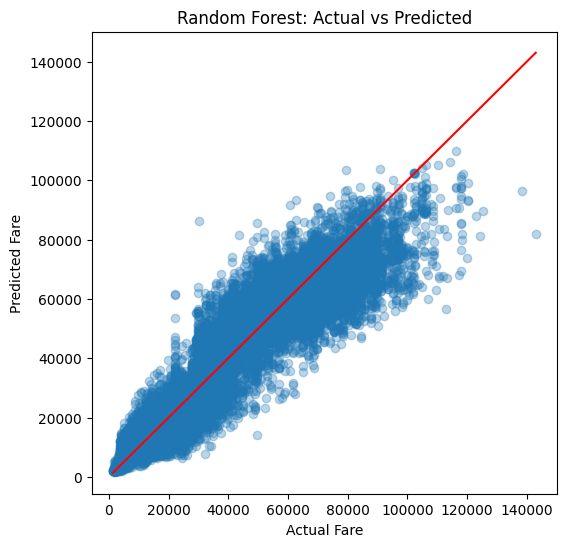

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

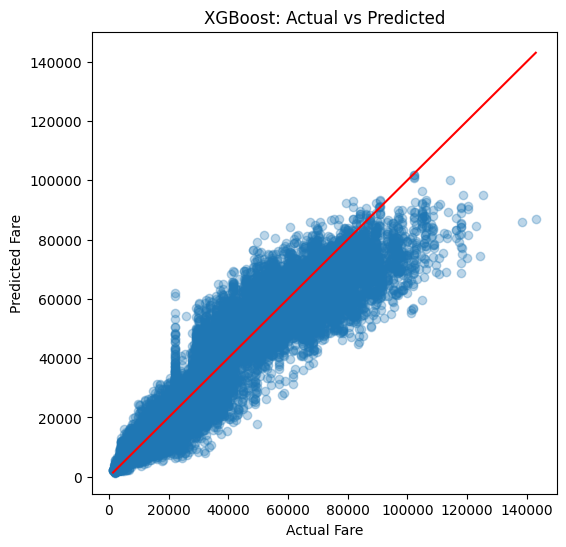

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_pred, alpha=0.3)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("XGBoost: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

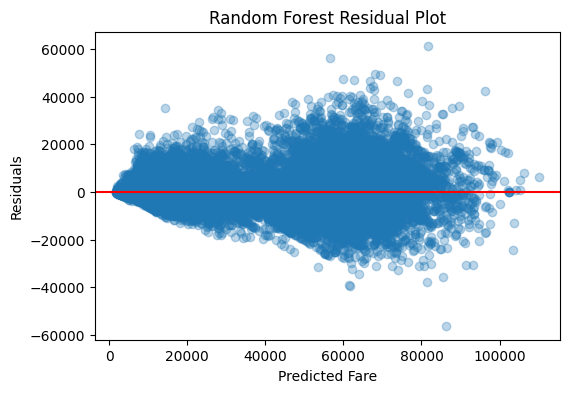

In [ ]:
rf_residuals = y_test - rf_pred

plt.figure(figsize=(6,4))
plt.scatter(rf_pred, rf_residuals, alpha=0.3)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()

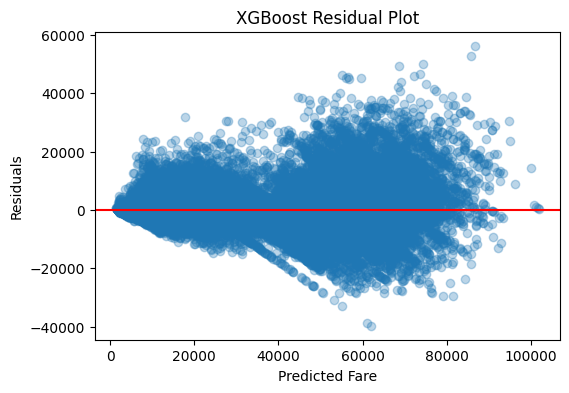

In [ ]:
xgb_residuals = y_test - xgb_pred

plt.figure(figsize=(6,4))
plt.scatter(xgb_pred, xgb_residuals, alpha=0.3)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("XGBoost Residual Plot")
plt.show()

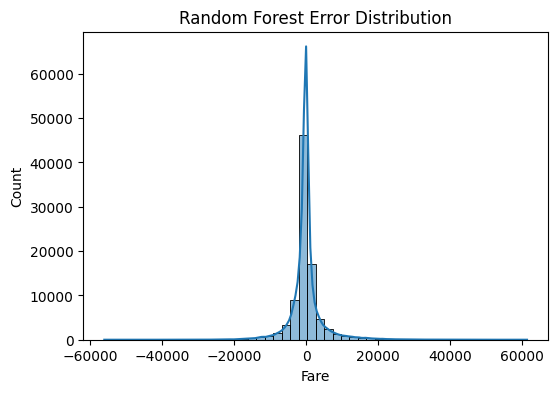

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(rf_residuals, bins=50, kde=True)
plt.title("Random Forest Error Distribution")
plt.show()

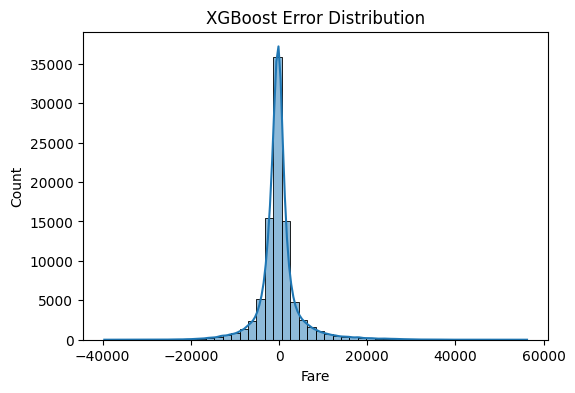

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(xgb_residuals, bins=50, kde=True)
plt.title("XGBoost Error Distribution")
plt.show()

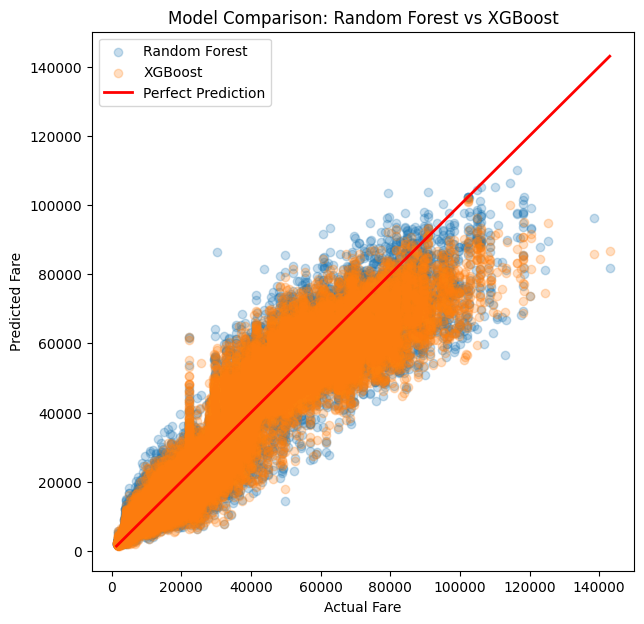

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_pred, alpha=0.25, label="Random Forest")

plt.scatter(y_test, xgb_pred, alpha=0.25, label="XGBoost")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Model Comparison: Random Forest vs XGBoost")
plt.legend()
plt.show()

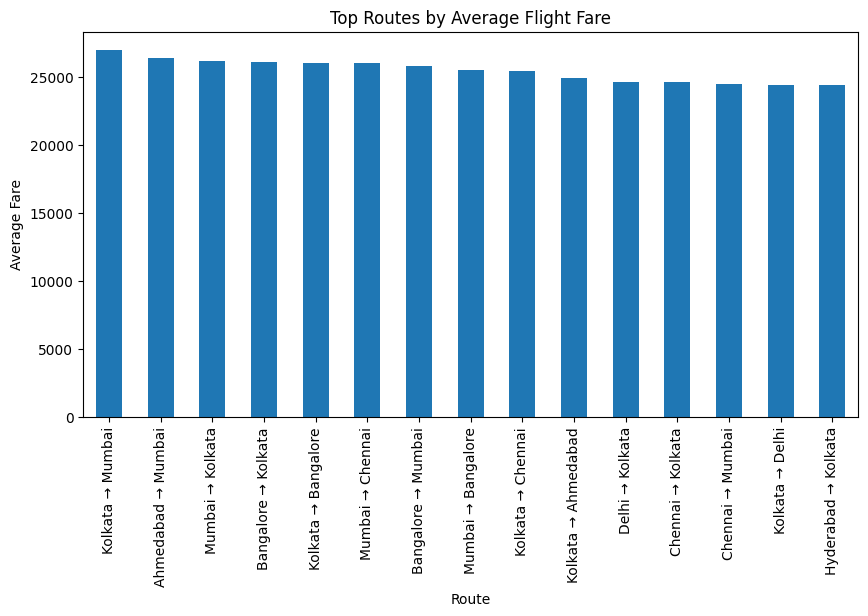

In [ ]:
df['Route'] = df['Source'] + " → " + df['Destination']

top_routes = df.groupby('Route')['Fare'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))
top_routes.plot(kind='bar')
plt.title("Top Routes by Average Flight Fare")
plt.ylabel("Average Fare")
plt.show()

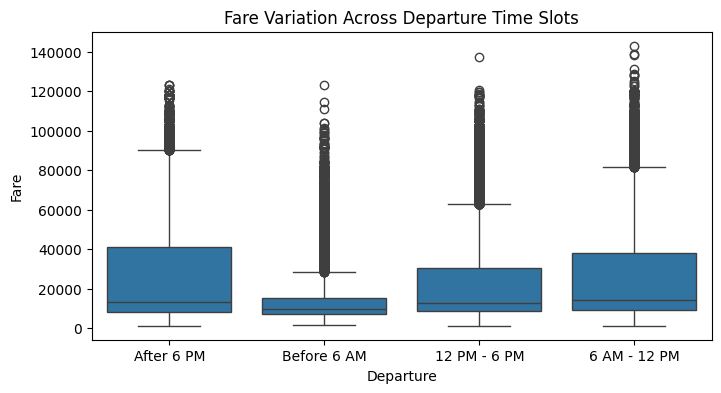

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Departure', y='Fare', data=df)
plt.title("Fare Variation Across Departure Time Slots")
plt.show()

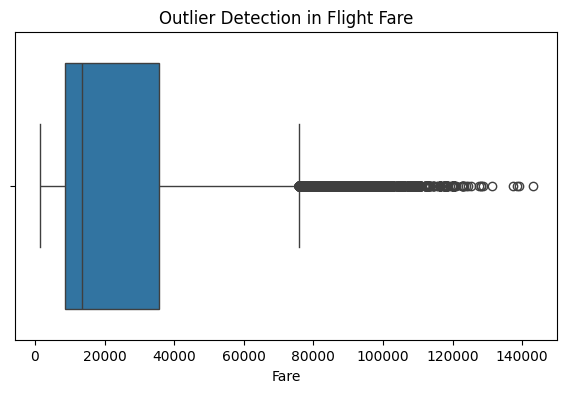

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['Fare'])
plt.title("Outlier Detection in Flight Fare")
plt.show()

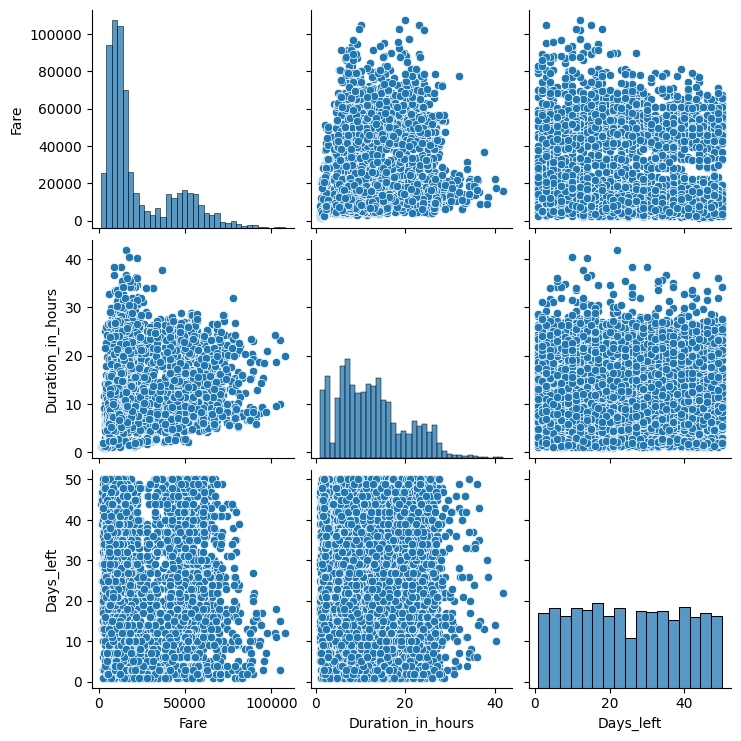

In [ ]:
sample_df = df.sample(5000)

sns.pairplot(sample_df[['Fare','Duration_in_hours','Days_left']])
plt.show()

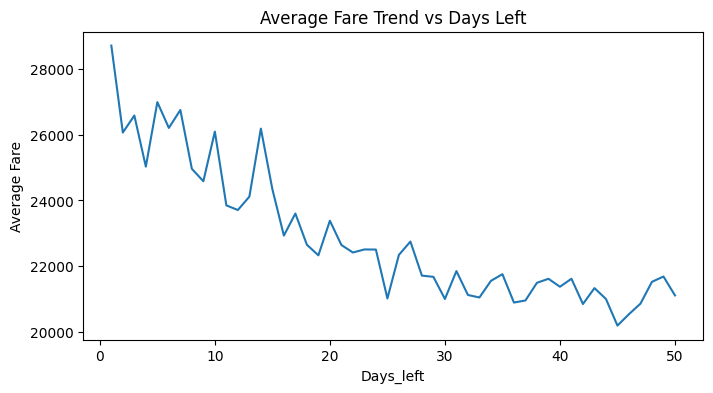

In [ ]:
avg_price = df.groupby('Days_left')['Fare'].mean()

plt.figure(figsize=(8,4))
avg_price.plot()
plt.title("Average Fare Trend vs Days Left")
plt.ylabel("Average Fare")
plt.show()